<a href="https://colab.research.google.com/github/Vansh-172/Project-Regression/blob/main/Vansh_Goyal_ML_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    -Regression
##### **Contribution**    - Individual
##### Name-Vansh Goyal

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/Vansh-172/Project-Regression

# **Problem Statement**


To predict if a person will have stroke or not

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [135]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

### Dataset Loading

In [136]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [137]:
# Load Dataset
path = '/content/drive/MyDrive/Colab Notebooks/Datasets/healthcare-dataset-stroke-data.csv'
df=pd.read_csv(path)

### Dataset First View

In [138]:
# Dataset First Look
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Dataset Rows & Columns count

In [139]:
   # Dataset Rows & Columns count
df.shape

(5110, 12)

### Dataset Information

In [140]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


#### Duplicate Values

In [141]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [142]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


<Axes: >

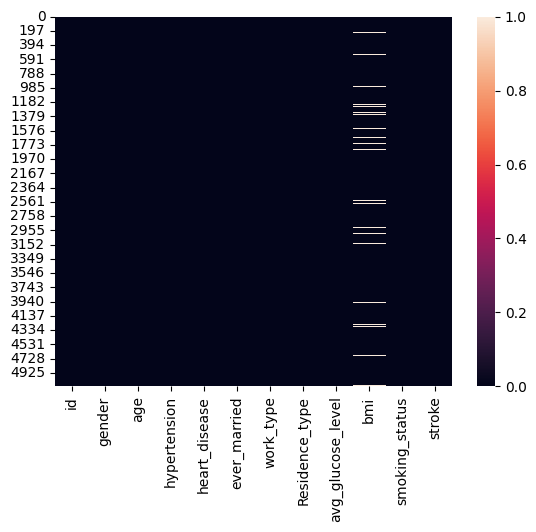

In [143]:
# Visualizing the missing values
sns.heatmap(df.isnull(),cbar=True)

### What did you know about your dataset?

The dataset gives information about the features of 5000 people that had/had no stroke , like age ,glucose levels , had hypertention or not, had heart diseases or not , were married or not and many more.

## ***2. Understanding Your Variables***

In [144]:
# Dataset Columns
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [145]:
# Dataset Describe
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### Variables Description

1) id: unique identifier
2) gender: "Male", "Female" or "Other"
3) age: age of the patient
4) hypertension: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
5) heart_disease: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
6) ever_married: "No" or "Yes"
7) work_type: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8) Residence_type: "Rural" or "Urban"
9) avg_glucose_level: average glucose level in blood
10) bmi: body mass index
11) smoking_status: "formerly smoked", "never smoked", "smokes" or "Unknown"*
12) stroke: 1 if the patient had a stroke or 0 if not

*Note: "Unknown" in smoking_status means that the information is unavailable for this patient

### Check Unique Values for each variable.

In [146]:
# Check Unique Values for each variable.
df.nunique()

,0
id,5110
gender,3
age,104
hypertension,2
heart_disease,2
ever_married,2
work_type,5
Residence_type,2
avg_glucose_level,3979
bmi,418


## 3. ***Data Wrangling***

### Data Wrangling Code

In [191]:
# Write your code to make your dataset analysis ready.
df.fillna(df['bmi'].median(),inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


### What all manipulations have you done and insights you found?

changed the null BMI rows with the median to reduce the effect of outliners in the column

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

In [148]:

# # --- 7. Hypertension and Stroke ---
# plt.figure(figsize=(6, 4))
# sns.countplot(data=df, x='hypertension', hue='stroke')
# plt.title('Insight 7: Hypertension vs. Stroke')
# plt.show()

# # --- 8. Heart Disease and Stroke ---
# plt.figure(figsize=(6, 4))
# sns.countplot(data=df, x='heart_disease', hue='stroke')
# plt.title('Insight 8: Heart Disease vs. Stroke')
# plt.show()

# # --- 9. Gender Differences ---
# plt.figure(figsize=(6, 4))
# sns.countplot(data=df, x='gender', hue='stroke')
# plt.title('Insight 9: Stroke Occurrence by Gender')
# plt.show()

# # --- 10. Work Type Impact ---
# plt.figure(figsize=(8, 5))
# sns.countplot(data=df, x='work_type', hue='stroke')
# plt.title('Insight 10: Stroke Occurrence by Work Type')
# plt.show()

# # --- 11. Residence Type ---
# plt.figure(figsize=(6, 4))
# sns.countplot(data=df, x='Residence_type', hue='stroke')
# plt.title('Insight 11: Stroke Occurrence by Residence Type')
# plt.show()

# # --- 12. Marriage Status, Age, and Stroke ---
# plt.figure(figsize=(8, 5))
# sns.boxplot(data=df, x='ever_married', y='age', hue='stroke')
# plt.title('Insight 12: Age and Marriage Status vs. Stroke')
# plt.show()

# # --- 13. Correlation Matrix Heatmap ---
# plt.figure(figsize=(10, 8))
# # Select only numerical/boolean columns for correlation
# numerical_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
# corr_matrix = df[numerical_cols].corr()

# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
# plt.title('Insight 13: Correlation Heatmap of Health Metrics')
# plt.show()

#### Chart - 1

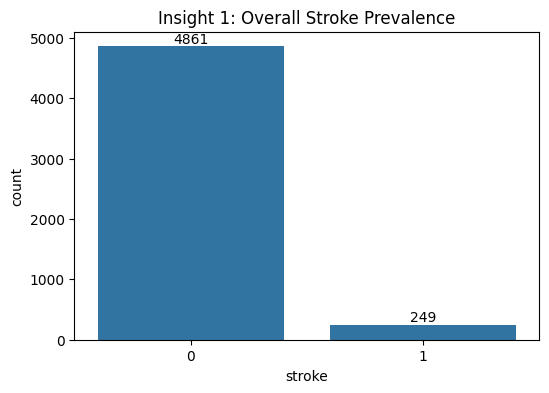

In [200]:
# Chart - 1 visualization code for chart
plt.figure(figsize=(6, 4))
ax=sns.countplot(data=df, x='stroke')
ax.bar_label(ax.containers[0])
plt.title('Insight 1: Overall Stroke Prevalence')
plt.show()

##### 1. Why did you pick the specific chart?

gives clear count of people having stroke and who don't

##### 2. What is/are the insight(s) found from the chart?

More than 4800 people didn't have stroke whereas less than 250 people had a stroke .

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

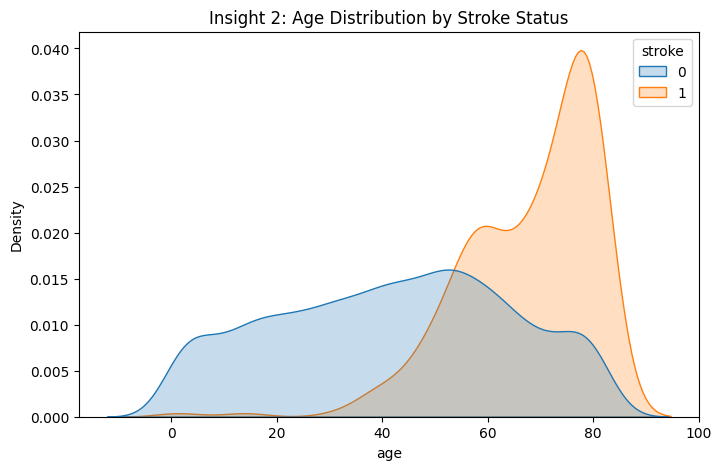

In [201]:
# Chart - 2 visualization code
# --- 2. Age vs. Stroke Risk ---
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='age', hue='stroke', fill=True, common_norm=False)
plt.title('Insight 2: Age Distribution by Stroke Status')
plt.show()

##### 1. Why did you pick the specific chart?

A density plot was chosen because it effectively visualizes the distribution of a continuous variable (age) across multiple categories (stroke status). Unlike histograms, it provides a smooth, continuous curve that clearly highlights where data is concentrated, making it easy to visually compare the overlapping age distributions without binning bias.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals that age is a significant risk factor for strokes. Patients who experienced a stroke (orange) are predominantly older, with the distribution peaking sharply around 75–80 years. Conversely, those without a stroke (blue) are distributed much more evenly across younger age groups, indicating stroke risk increases significantly with age

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

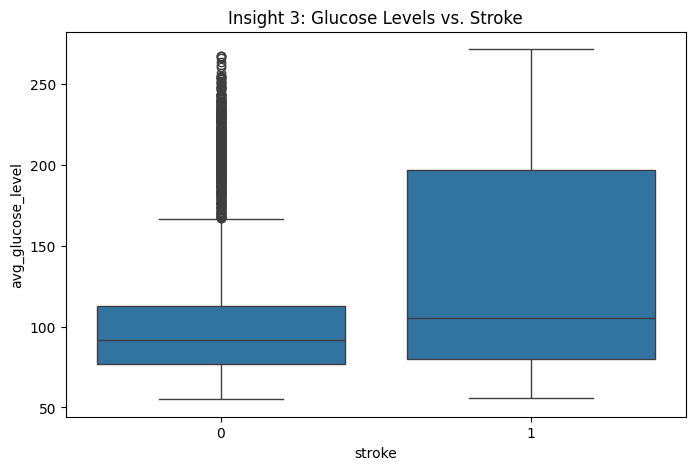

In [206]:
# Chart - 3 visualization code
# --- 3. Average Glucose Level by Stroke ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='stroke', y='avg_glucose_level')
plt.title('Insight 3: Glucose Levels vs. Stroke')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is ideal for comparing the distribution of a continuous variable (glucose level) across categorical groups (stroke status). It clearly displays the median, data spread, and highlights outliers. This makes it easy to visually contrast the glucose ranges between patients with and without strokes.

##### 2. What is/are the insight(s) found from the chart?

Patients who had a stroke generally exhibit a wider range of average glucose levels and a slightly higher median compared to those without a stroke. While the non-stroke group has many high-glucose outliers, a larger portion of stroke patients have consistently higher glucose levels, suggesting a potential correlation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

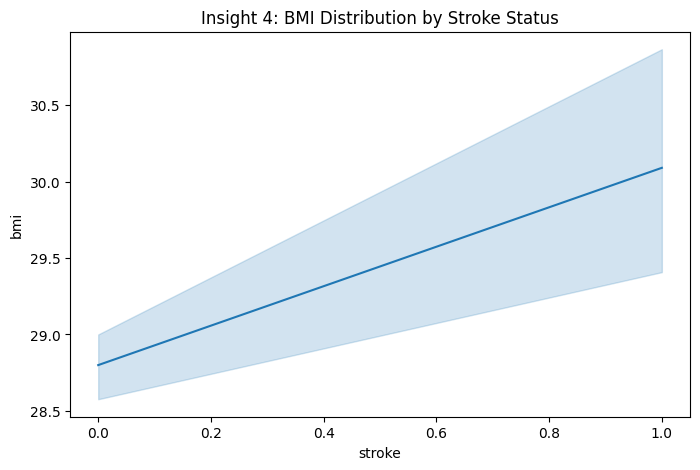

In [209]:
# Chart - 4 visualization code
# --- 4. BMI Distribution by Stroke ---
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x='stroke', y='bmi')
plt.title('Insight 4: BMI Distribution by Stroke Status')
plt.show()

##### 1. Why did you pick the specific chart?

A line plot with a shaded confidence interval effectively emphasizes the difference in average values between groups. Although stroke status is binary, this visualization highlights the upward shift in mean BMI and clearly displays the statistical uncertainty (variance) surrounding the averages of both groups.

##### 2. What is/are the insight(s) found from the chart?

Patients who had a stroke (1) show a higher average BMI (30) compared to those without (~28.8). The significantly wider shaded band for the stroke group indicates greater uncertainty around this average, which directly reflects the much smaller sample size of stroke patients in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

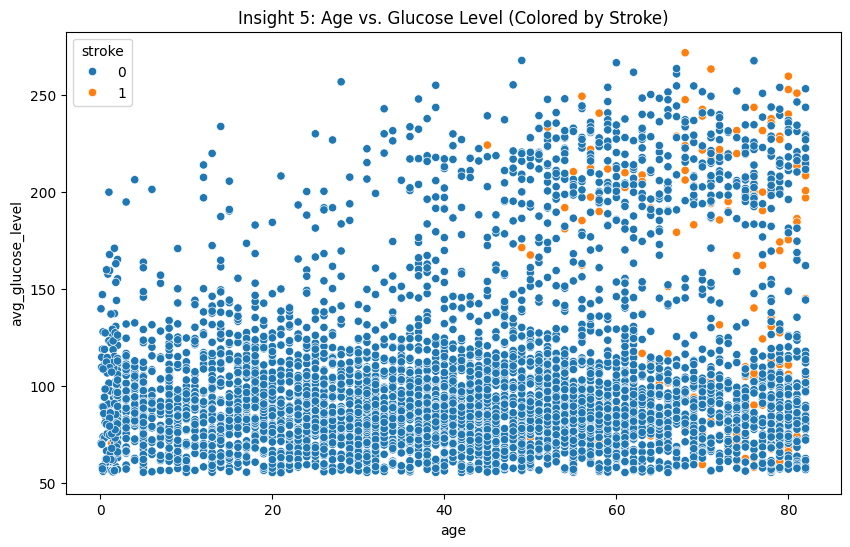

In [215]:
# Chart - 5 visualization code
# --- 5. Age vs. Average Glucose Level ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='avg_glucose_level', hue='stroke', alpha=1)
plt.title('Insight 5: Age vs. Glucose Level (Colored by Stroke)')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is the most effective way to visualize the relationship between two continuous variables simultaneously—in this case, age and average glucose level. By adding color-coding for stroke status, it allows us to quickly identify clusters, correlations, and multi-variable risk patterns within the raw data points.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals a compounded risk factor: strokes (orange dots) are heavily clustered in older age brackets (above 50). Furthermore, older patients who also suffer from unusually high average glucose levels (above 150) show a noticeably denser concentration of strokes, suggesting that age and elevated glucose combined increase risk.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

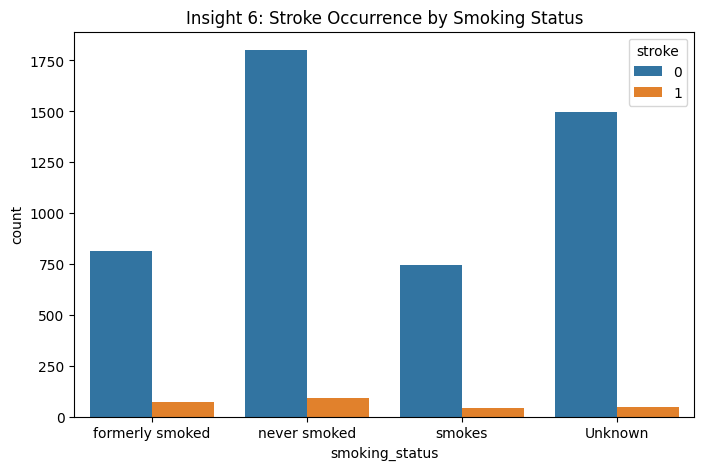

In [216]:
# Chart - 6 visualization code
# --- 6. Impact of Smoking Status ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='smoking_status', hue='stroke')
plt.title('Insight 6: Stroke Occurrence by Smoking Status')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart was selected because it effectively compares the absolute frequencies of a binary outcome (stroke vs. no stroke) across multiple discrete categories (smoking status). This side-by-side layout allows for quick visual assessment of stroke proportions within each distinct group.

##### 2. What is/are the insight(s) found from the chart?

While the "never smoked" category has the highest total number of strokes due to its large overall sample size, the "formerly smoked" group shows the highest proportion of strokes relative to its size. The large "Unknown" category also highlights significant missing data that could obscure smoking's true impact.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

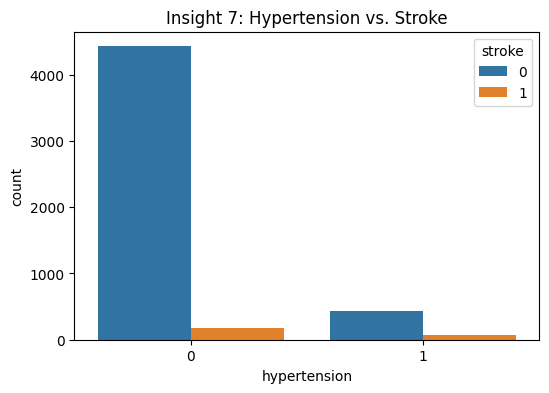

In [217]:
# Chart - 7 visualization code
# --- 7. Hypertension and Stroke ---
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='hypertension', hue='stroke')
plt.title('Insight 7: Hypertension vs. Stroke')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart was chosen because it allows for a direct comparison of a binary outcome (stroke occurrence) within another binary categorical variable (hypertension). By plotting counts side-by-side, it clearly illustrates both the absolute frequencies and relative proportions of strokes for patients with and without hypertension.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that while the vast majority of patients do not have hypertension, those who do (hypertension = 1) experience a notably higher proportion of strokes compared to those without. This indicates that hypertension is a significant contributing risk factor for stroke occurrence within this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

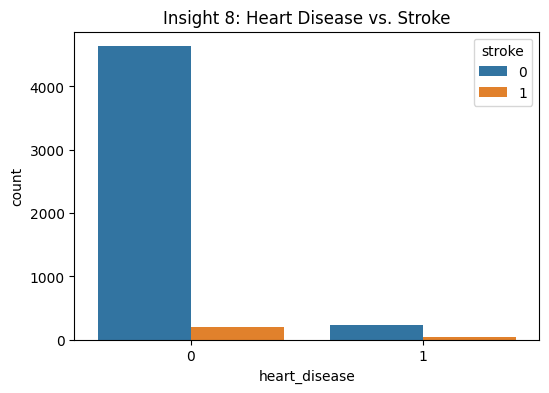

In [218]:
# Chart - 8 visualization code
# --- 8. Heart Disease and Stroke ---
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='heart_disease', hue='stroke')
plt.title('Insight 8: Heart Disease vs. Stroke')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart was selected because it effectively compares the absolute counts of a binary outcome (stroke) across another binary category (heart disease). Plotting the counts side-by-side visually emphasizes both the overall rarity of heart disease in the dataset and the relative stroke proportions within each group.

##### 2. What is/are the insight(s) found from the chart?

The chart indicates that most patients do not have heart disease. However, for those who do (heart_disease = 1), the proportion of strokes is noticeably higher compared to those without heart disease. This suggests that pre-existing heart disease is a substantial risk factor for experiencing a stroke.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

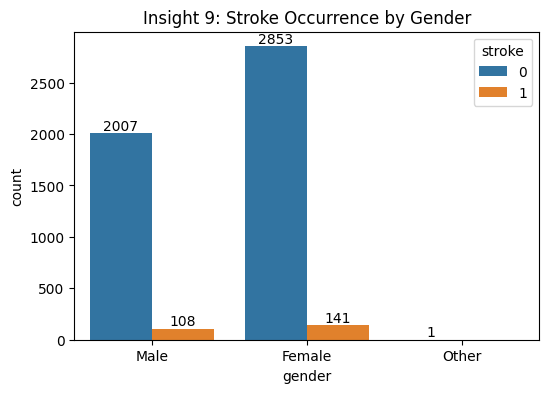

In [232]:
# Chart - 9 visualization code
# --- 9. Gender Differences ---
plt.figure(figsize=(6, 4))
ax=sns.countplot(data=df, x='gender', hue='stroke')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Insight 9: Stroke Occurrence by Gender')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart with data labels was chosen to directly compare absolute counts of a binary outcome (stroke) across gender categories. Adding exact numerical labels on the bars eliminates guesswork, making it exceptionally clear to read exact sample sizes and specific outcome distributions simultaneously without relying on the axis.

##### 2. What is/are the insight(s) found from the chart?

The dataset contains significantly more females than males, leading to a higher absolute number of strokes in females (141 versus 108). However, the actual proportion of strokes within each gender is relatively similar , suggesting gender alone isn't a dominant risk differentiator.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

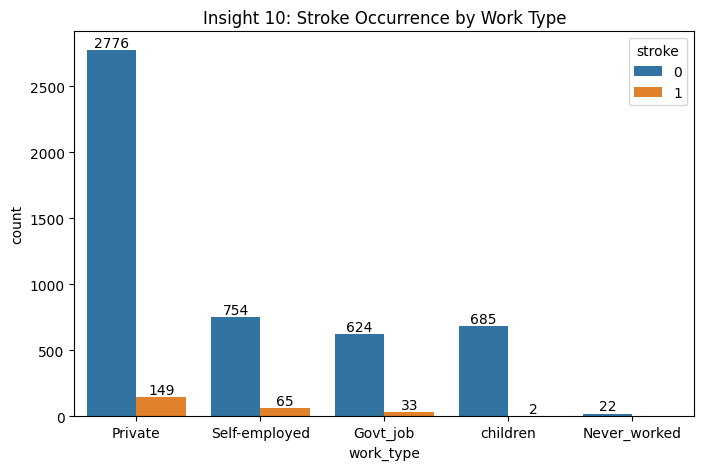

In [234]:
# Chart - 10 visualization code
# --- 10. Work Type Impact ---
plt.figure(figsize=(8, 5))
ax=sns.countplot(data=df, x='work_type', hue='stroke')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Insight 10: Stroke Occurrence by Work Type')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [159]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [160]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [161]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [162]:
# Correlation Heatmap visualization code


##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

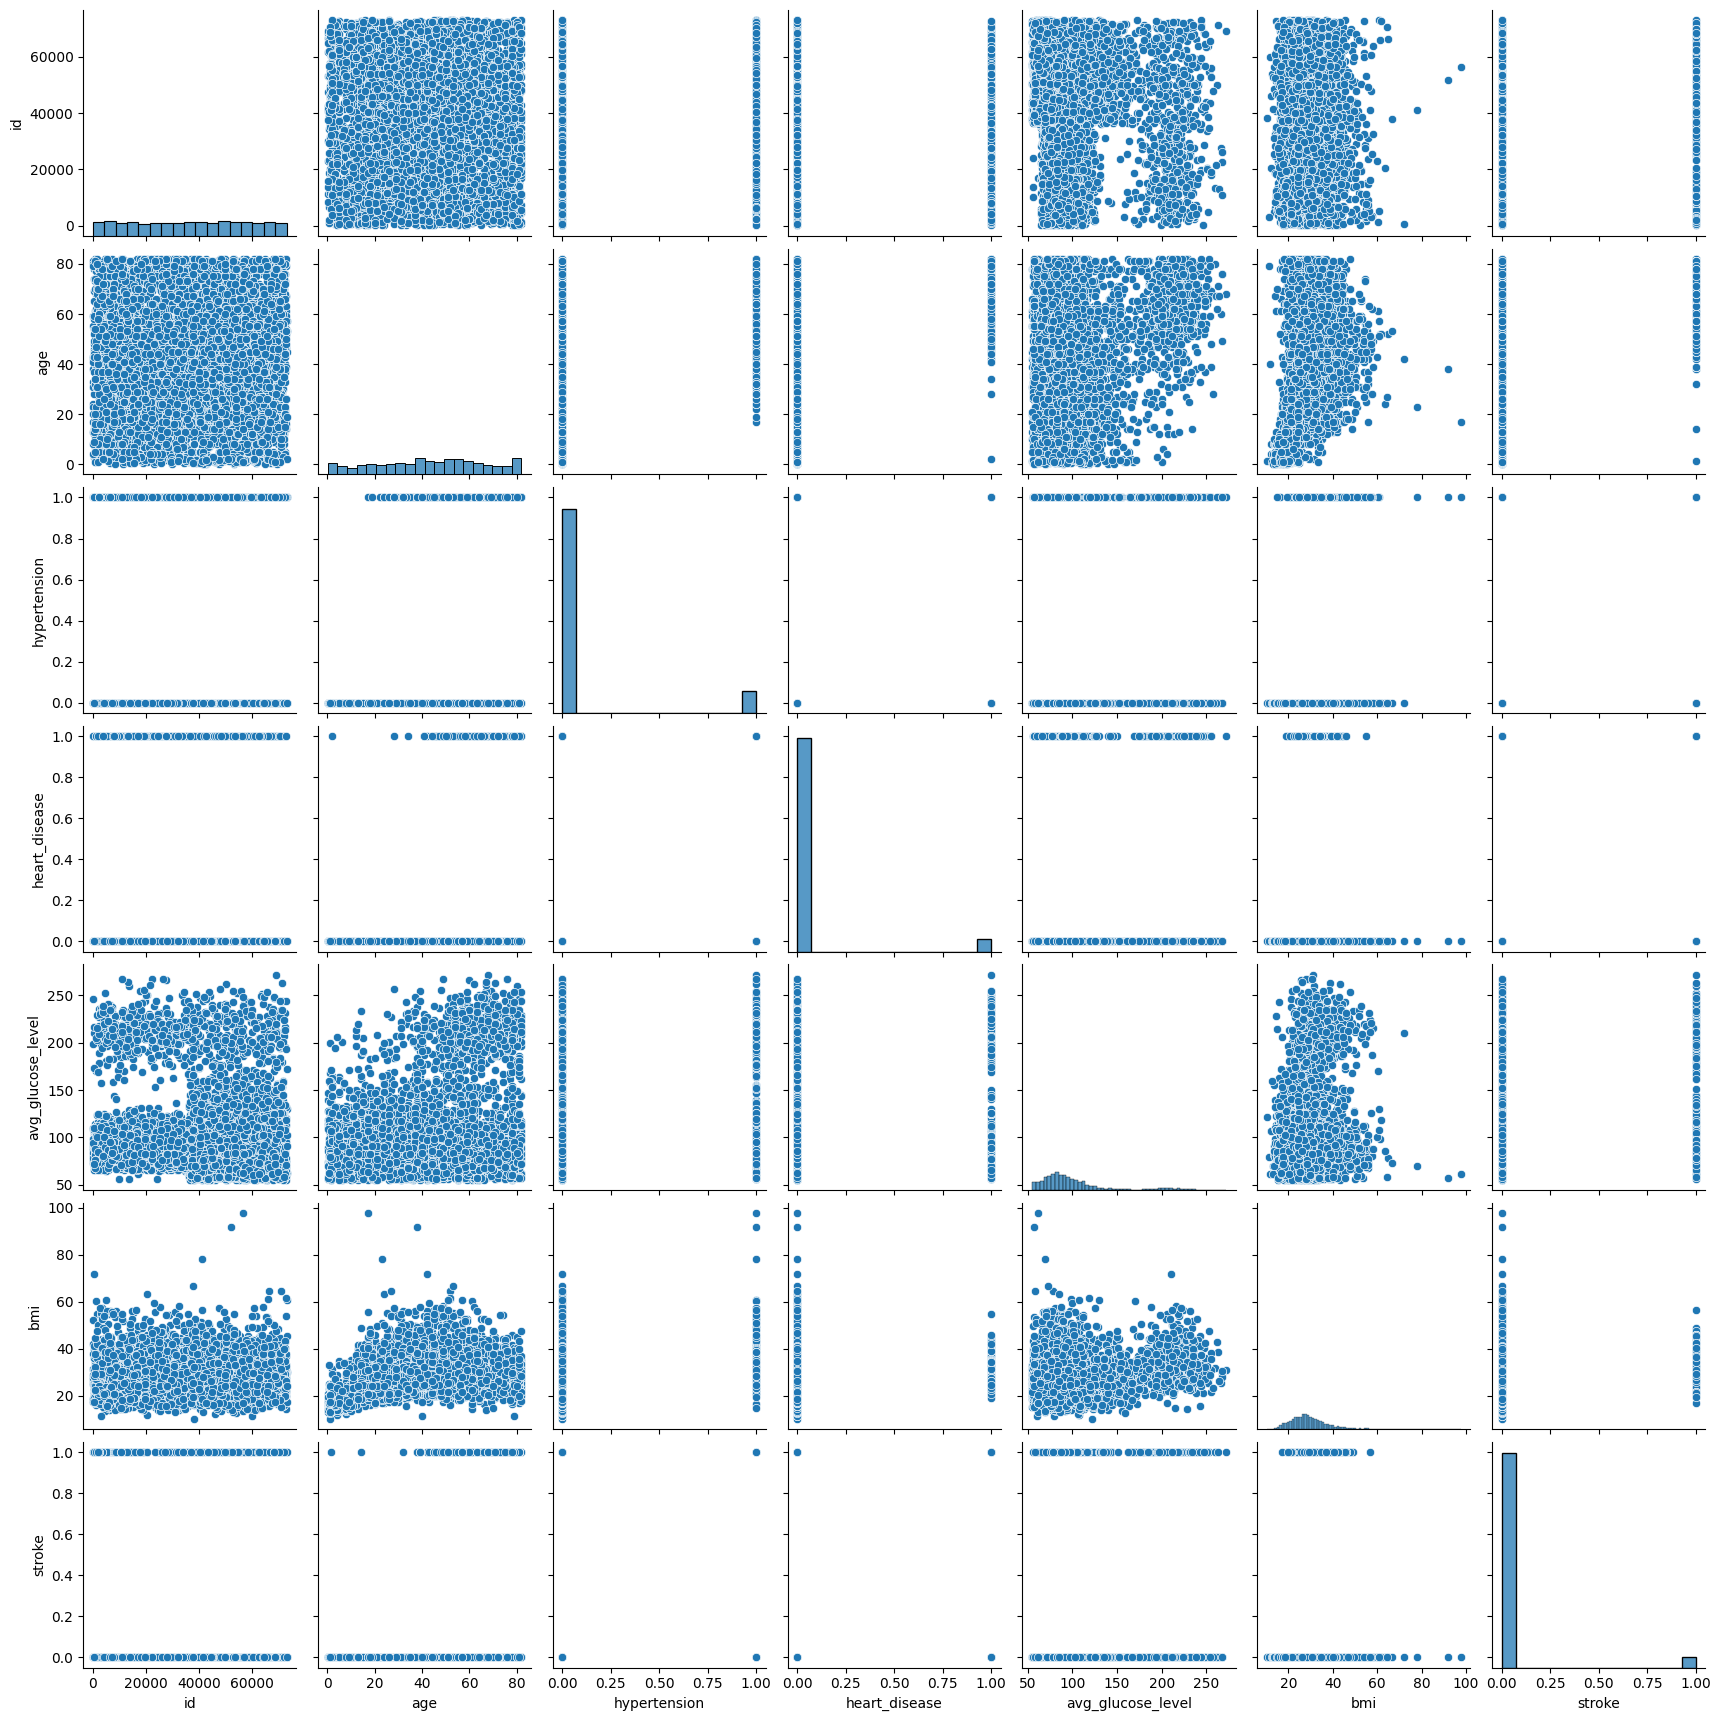

In [163]:
# Pair Plot visualization code
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [164]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [165]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [166]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [167]:
# Expand Contraction

#### 2. Lower Casing

In [168]:
# Lower Casing

#### 3. Removing Punctuations

In [169]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [170]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [171]:
# Remove Stopwords

In [172]:
# Remove White spaces

#### 6. Rephrase Text

In [173]:
# Rephrase Text

#### 7. Tokenization

In [174]:
# Tokenization

#### 8. Text Normalization

In [175]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [176]:
# POS Taging

#### 10. Text Vectorization

In [177]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [178]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [179]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [180]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [181]:
# Split your data to train and test. Choose Splitting ratio wisely.
# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

##### What data splitting ratio have you used and why?

I have used 20% splitting ratio as it is most suitable , for training and testing data model

## ***7. ML Model Implementation***

### ML Model - 1

In [182]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [183]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [184]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [185]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [186]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [187]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [188]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [189]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***